<a href="https://colab.research.google.com/github/A-ghori/sklearn/blob/main/MPG_DATASET_SINGLE_TARGET_REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import kagglehub
import os
import numpy as np
import pandas as pd


# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")
csv_file = os.path.join(path, "auto-mpg.csv")
df = pd.read_csv(csv_file)
df.head()
#print("Path to dataset files:", path)

Using Colab cache for faster access to the 'autompg-dataset' dataset.


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [15]:
def calculate_median(values):
  sorted_vals = sorted([v for v in values if v == v])
  n = len(sorted_vals)

  if n == 0 :
    return None

  mid = n // 2

  if n % 2 != 0 :
    # odd count : middle element

    return float(sorted_vals[mid])
  else :
    return (sorted_vals[mid - 1] + sorted_vals[mid]) / 2.0

  print(calculate_median([7,2,9,3,5]))
  print(calculate_median([7,2,9,3,5,10]))

In [16]:
df.info()

df['horsepower'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [17]:
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

print("Missing Horsepower Count:", df["horsepower"]. isna().sum())

print("Column dtpye:", df["horsepower"].dtype)

Missing Horsepower Count: 6
Column dtpye: float64


In [18]:
df['horsepower'].unique()


array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [19]:
print("Mean Horsepower:", df["horsepower"].mean())

Mean Horsepower: 104.46938775510205


In [20]:
print("Median Horsepower", df["horsepower"].median())

Median Horsepower 93.5


In [21]:
print("Skewness", df["horsepower"].skew() )

Skewness 1.0873262824048695


In [22]:
median_hp = calculate_median(df["horsepower"])
df["horsepower"] = df["horsepower"].fillna(median_hp)
print(median_hp)
print("Remainning null : ", df["horsepower"].isna().sum())

93.5
Remainning null :  0


In [23]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [24]:
df = df.drop(columns=["car name"])

In [28]:
df["car name"].unique()

KeyError: 'car name'

In [29]:
df["mpg"].unique()

array([18. , 15. , 16. , 17. , 14. , 24. , 22. , 21. , 27. , 26. , 25. ,
       10. , 11. ,  9. , 28. , 19. , 12. , 13. , 23. , 30. , 31. , 35. ,
       20. , 29. , 32. , 33. , 17.5, 15.5, 14.5, 22.5, 24.5, 18.5, 29.5,
       26.5, 16.5, 31.5, 36. , 25.5, 33.5, 20.5, 30.5, 21.5, 43.1, 36.1,
       32.8, 39.4, 19.9, 19.4, 20.2, 19.2, 25.1, 20.6, 20.8, 18.6, 18.1,
       17.7, 27.5, 27.2, 30.9, 21.1, 23.2, 23.8, 23.9, 20.3, 21.6, 16.2,
       19.8, 22.3, 17.6, 18.2, 16.9, 31.9, 34.1, 35.7, 27.4, 25.4, 34.2,
       34.5, 31.8, 37.3, 28.4, 28.8, 26.8, 41.5, 38.1, 32.1, 37.2, 26.4,
       24.3, 19.1, 34.3, 29.8, 31.3, 37. , 32.2, 46.6, 27.9, 40.8, 44.3,
       43.4, 36.4, 44.6, 40.9, 33.8, 32.7, 23.7, 23.6, 32.4, 26.6, 25.8,
       23.5, 39.1, 39. , 35.1, 32.3, 37.7, 34.7, 34.4, 29.9, 33.7, 32.9,
       31.6, 28.1, 30.7, 24.2, 22.4, 34. , 38. , 44. ])

In [30]:
correlations = df.corr(numeric_only=True)["mpg"].sort_values()
print(correlations)

weight         -0.831741
displacement   -0.804203
cylinders      -0.775396
horsepower     -0.773453
acceleration    0.420289
origin          0.563450
model year      0.579267
mpg             1.000000
Name: mpg, dtype: float64


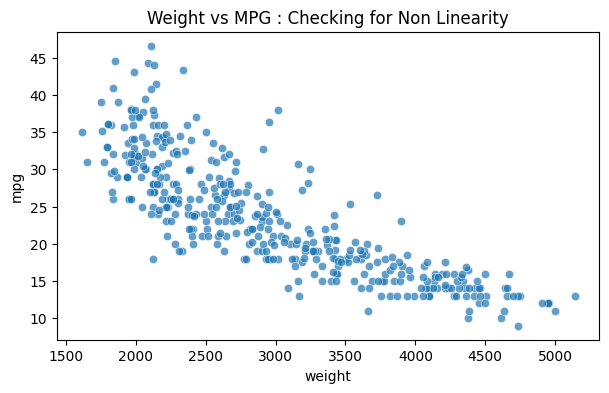

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt .figure(figsize=(7,4))
sns.scatterplot(data=df, x="weight", y="mpg", alpha=0.7)
plt.title("Weight vs MPG : Checking for Non Linearity")
plt.show()


In [32]:
X = df.drop(columns=["mpg"])
y = df["mpg"]

print("Features shape (X) : ", X.shape)
print("Target shape(y) : ", y.shape)

Features shape (X) :  (398, 7)
Target shape(y) :  (398,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")

Training samples: 318 | Test samples: 80


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)



LinearRegression()

In [39]:
y_pred_lr = model.predict(X_test_scaled)
print(y_pred_lr)

[32.88140046 29.55780381 21.36955005 16.79734409 12.4982001  27.20579297
 27.90034172  9.77551057 16.88434148 22.03432001 12.80789558 36.15459303
 25.17028795 13.69410403 23.9851906   6.38676545 29.53717565 23.57394424
 16.32934475 36.28649078 23.71277029 18.98644465 28.71675729 28.74222236
 14.9937939  34.66185682 25.48371184 24.95050273 21.94949529  8.78921085
 28.43042198 34.85784604 20.52566418 26.07137821 34.25192799 11.98882056
 22.93388155 21.74271783 12.32731516 26.75009008 26.24028149 27.42358817
 20.15034925  7.2688964  24.53759706 34.94012278 26.75746176 24.19444148
 22.51366966 27.5625466  22.68143886 33.67127815 32.67124307 10.95619387
 27.70684405 10.00691734 19.76572214 29.87443683 23.17483434 20.47189168
 16.18259662 32.09331845 24.02025492 20.49935146 20.92671853 25.51057393
 25.11923146 32.38245245 28.07654777 12.71391714 31.2720768  13.02792301
 10.04768517 19.42898455 27.39271123 22.12731743 20.51995099 29.52906034
 29.33325802 20.0870444 ]


In [40]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred_lr)
print(acc)

ValueError: continuous is not supported

In [41]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- {name} Performance ---")
    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : {mae:.2f} mpg")
    print(f"RMSE     : {rmse:.2f} mpg\n")


evaluate_model("Linear Regression", y_test, y_pred_lr)


--- Linear Regression Performance ---
R² Score : 0.8475
MAE      : 2.26 mpg
RMSE     : 2.86 mpg

